# 04 — BLS / FRED EDA: US Calibration Baseline

**Phase 1, Week 2 — independent EDA of US labour statistics for project calibration.**

**Goal:** Extract headline US numbers on (i) voluntary turnover (JOLTS quits rate), (ii) earnings, (iii) sickness absence. These feed into US ROI calculations and provide a transatlantic comparison against the UK calibration baseline.

**Datasets:**
- `JTSQUR.xlsx` — JOLTS US Quits Rate, total nonfarm, monthly seasonally adjusted (FRED mirror of BLS JOLTS, series JTSQUR)
- `CES0500000030.xlsx` — US Average Weekly Earnings, all employees, total private (FRED mirror of BLS CES, series CES0500000030)
- `cpsa2025.xlsx` — BLS CPS Absences from Work, annual averages 2024

**Approach:** Light EDA — these are pre-aggregated official statistics. We extract headline numbers, plot trends, and compare against UK figures from notebook 03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

PROJECT_ROOT = Path.cwd().parent
BLS_DIR = PROJECT_ROOT / "data" / "external" / "bls"
OUTPUTS_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"

# File paths
JOLTS_PATH = BLS_DIR / "JTSQUR.xlsx"
EARNINGS_PATH = BLS_DIR / "CES0500000030.xlsx"
ABSENCE_PATH = BLS_DIR / "cpsa2025.xlsx"

# Confirm files exist
for path in [JOLTS_PATH, EARNINGS_PATH, ABSENCE_PATH]:
    print(f"{path.name}: {'✓' if path.exists() else '✗ MISSING'}")

JTSQUR.xlsx: ✓
CES0500000030.xlsx: ✓
cpsa2025.xlsx: ✓


---

## Part 1: JOLTS — US voluntary turnover (quits rate)

Monthly US quits rate (% of US workforce who voluntarily left per month) from FRED series `JTSQUR`. Data from March 2016 to March 2026 — 121 monthly observations.

**Why this is the cleanest available US "regrettable attrition" measure:** unlike UK RTI total outflows, JOLTS *separately* reports quits (voluntary), layoffs, and other separations from the start. The quits rate maps directly to the regrettable-attrition concept Wellmatch addresses.

In [2]:
# Load JOLTS quits rate
# FRED format: README sheet + Monthly sheet
jolts = pd.read_excel(JOLTS_PATH, sheet_name='Monthly')
jolts.columns = ['date', 'quits_rate_pct']
jolts['date'] = pd.to_datetime(jolts['date'])
jolts['quits_rate_pct'] = pd.to_numeric(jolts['quits_rate_pct'])

print(f"Records: {len(jolts)}")
print(f"Period: {jolts['date'].min().strftime('%b %Y')} – {jolts['date'].max().strftime('%b %Y')}")
print(f"\nFirst 3 months:")
print(jolts.head(3).to_string(index=False))
print(f"\nLast 3 months:")
print(jolts.tail(3).to_string(index=False))

# Headline US figures
latest_rate = jolts.iloc[-1]['quits_rate_pct']
peak_rate = jolts['quits_rate_pct'].max()
peak_date = jolts.loc[jolts['quits_rate_pct'].idxmax(), 'date']
mean_rate = jolts['quits_rate_pct'].mean()

# Annualised (monthly × 12)
latest_annualised = latest_rate * 12
peak_annualised = peak_rate * 12

print(f"\n>>> KEY US CALIBRATION NUMBERS <<<")
print(f"Latest US monthly quits rate ({jolts.iloc[-1]['date'].strftime('%b %Y')}): {latest_rate}%")
print(f"Annualised: ~{latest_annualised:.1f}%")
print(f"\nPeak US monthly rate (Great Resignation): {peak_rate}% in {peak_date.strftime('%b %Y')}")
print(f"Annualised at peak: ~{peak_annualised:.1f}%")
print(f"\n10-year mean: {mean_rate:.2f}%")

# UK comparison from notebook 03
print(f"\n>>> US vs UK COMPARISON <<<")
print(f"US annualised quits rate (2026):     ~{latest_annualised:.1f}%")
print(f"UK regrettable attrition (estimated): ~10.5%")
print(f"US/UK ratio:                          ~{latest_annualised/10.5:.1f}× higher in the US")

Records: 121
Period: Mar 2016 – Mar 2026

First 3 months:
      date  quits_rate_pct
2016-03-01             2.0
2016-04-01             2.1
2016-05-01             2.1

Last 3 months:
      date  quits_rate_pct
2026-01-01             2.0
2026-02-01             1.9
2026-03-01             2.0

>>> KEY US CALIBRATION NUMBERS <<<
Latest US monthly quits rate (Mar 2026): 2.0%
Annualised: ~24.0%

Peak US monthly rate (Great Resignation): 3.0% in Nov 2021
Annualised at peak: ~36.0%

10-year mean: 2.28%

>>> US vs UK COMPARISON <<<
US annualised quits rate (2026):     ~24.0%
UK regrettable attrition (estimated): ~10.5%
US/UK ratio:                          ~2.3× higher in the US


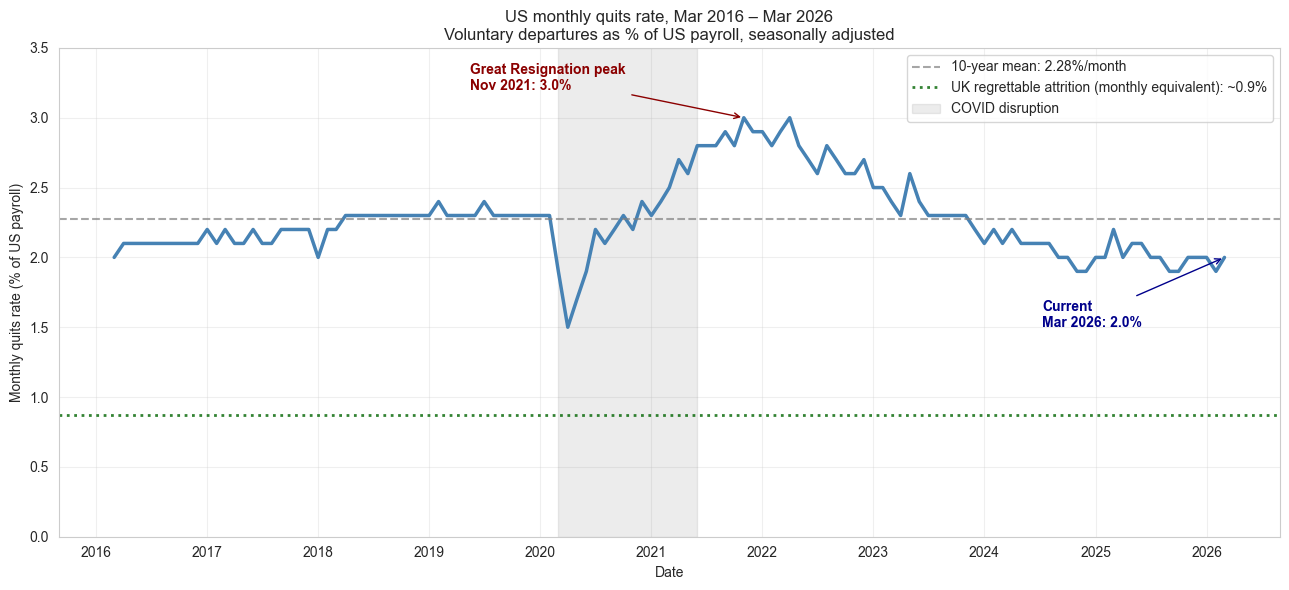

In [3]:
# Plot US monthly quits rate over time
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(jolts['date'], jolts['quits_rate_pct'], 
        linewidth=2.5, color='steelblue')

# Annotate Great Resignation peak
peak_idx = jolts['quits_rate_pct'].idxmax()
peak_row = jolts.iloc[peak_idx]
ax.annotate(f'Great Resignation peak\n{peak_row["date"].strftime("%b %Y")}: {peak_row["quits_rate_pct"]}%',
            xy=(peak_row['date'], peak_row['quits_rate_pct']),
            xytext=(peak_row['date'] - pd.Timedelta(days=900), peak_row['quits_rate_pct'] + 0.2),
            fontsize=10, color='darkred', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred'))

# Annotate current
latest_row = jolts.iloc[-1]
ax.annotate(f'Current\n{latest_row["date"].strftime("%b %Y")}: {latest_row["quits_rate_pct"]}%',
            xy=(latest_row['date'], latest_row['quits_rate_pct']),
            xytext=(latest_row['date'] - pd.Timedelta(days=600), latest_row['quits_rate_pct'] - 0.5),
            fontsize=10, color='darkblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkblue'))

# 10-year mean reference
ax.axhline(mean_rate, color='gray', linestyle='--', alpha=0.7,
           label=f'10-year mean: {mean_rate:.2f}%/month')

# UK comparison reference — UK ~10.5% annual regrettable ≈ ~0.9% monthly
uk_monthly_equivalent = 10.5 / 12
ax.axhline(uk_monthly_equivalent, color='darkgreen', linestyle=':', linewidth=2, alpha=0.8,
           label=f'UK regrettable attrition (monthly equivalent): ~{uk_monthly_equivalent:.1f}%')

# Shade COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='gray', label='COVID disruption')

ax.set_xlabel('Date')
ax.set_ylabel('Monthly quits rate (% of US payroll)')
ax.set_title('US monthly quits rate, Mar 2016 – Mar 2026\nVoluntary departures as % of US payroll, seasonally adjusted')
ax.legend(loc='upper right')
ax.set_ylim(0, 3.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'bls_jolts_quits_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part 2: CES — US average weekly earnings

Average weekly earnings for all employees on US private nonfarm payrolls (FRED series `CES0500000030`). Used to compute US daily wage, which combined with the US absence rate gives the headline US £ cost of absence calibration.

In [4]:
# Inspect CES earnings file structure
import openpyxl
wb = openpyxl.load_workbook(EARNINGS_PATH, data_only=True)
print(f"Sheets: {wb.sheetnames}")
for name in wb.sheetnames:
    ws = wb[name]
    print(f"\n=== '{name}' — {ws.max_row} rows × {ws.max_column} cols ===")
    for i, row in enumerate(ws.iter_rows(values_only=True)):
        if i > 12:
            print("...")
            break
        non_empty = [str(c) if c is not None else '' for c in row]
        print(f"  row {i+1}: {non_empty}")

Sheets: ['README', 'Monthly']

=== 'README' — 8 rows × 3 cols ===
  row 1: ['FRED Graph Observations', '', '']
  row 2: ['Federal Reserve Economic Data, Federal Reserve Bank of St. Louis', '', '']
  row 3: ['Link: https://fred.stlouisfed.org', '', '']
  row 4: ['Help: https://fredhelp.stlouisfed.org', '', '']
  row 5: ['This data may be copyrighted. Please refer to the Terms of Use: https://fred.stlouisfed.org/legal#fred-terms-faq', '', '']
  row 6: ['File Created: 2026-05-27 7:31 am CDT', '', '']
  row 7: ['', '', '']
  row 8: ['CES0500000030', 'Average Weekly Earnings of Production and Nonsupervisory Employees, Total Private, Dollars per Week, Monthly, Seasonally Adjusted', 'Data Updated: 2026-05-08']

=== 'Monthly' — 122 rows × 2 cols ===
  row 1: ['observation_date', 'CES0500000030']
  row 2: ['2016-04-01 00:00:00', '721.06']
  row 3: ['2016-05-01 00:00:00', '721.73']
  row 4: ['2016-06-01 00:00:00', '723.07']
  row 5: ['2016-07-01 00:00:00', '725.09']
  row 6: ['2016-08-01 00:00:0

In [5]:
# Load CES earnings
earnings = pd.read_excel(EARNINGS_PATH, sheet_name='Monthly')
earnings.columns = ['date', 'weekly_earnings_usd']
earnings['date'] = pd.to_datetime(earnings['date'])
earnings['weekly_earnings_usd'] = pd.to_numeric(earnings['weekly_earnings_usd'])

print(f"Records: {len(earnings)}")
print(f"Period: {earnings['date'].min().strftime('%b %Y')} – {earnings['date'].max().strftime('%b %Y')}")

# Headline figures
latest = earnings.iloc[-1]
earliest = earnings.iloc[0]
print(f"\nLatest month ({latest['date'].strftime('%b %Y')}):")
print(f"  US weekly earnings (production/nonsup): ${latest['weekly_earnings_usd']:.2f}")
print(f"  Implied daily (÷ 5):                    ${latest['weekly_earnings_usd']/5:.2f}")
print(f"  Implied annual (× 52):                  ${latest['weekly_earnings_usd']*52:,.0f}")

# Growth
print(f"\nGrowth since {earliest['date'].strftime('%b %Y')}: ${earliest['weekly_earnings_usd']:.0f} → ${latest['weekly_earnings_usd']:.0f}")
print(f"({(latest['weekly_earnings_usd']/earliest['weekly_earnings_usd'] - 1)*100:.0f}% nominal growth over 10 years)")

# Convert to GBP for direct UK comparison
# Approximate exchange rate as of May 2026 (worth checking the actual rate when documenting)
USD_TO_GBP = 0.78  # approximate
latest_weekly_gbp = latest['weekly_earnings_usd'] * USD_TO_GBP
latest_daily_gbp = latest_weekly_gbp / 5

print(f"\n>>> US vs UK EARNINGS COMPARISON <<<")
print(f"(Using approximate exchange rate: $1 = £{USD_TO_GBP})")
print(f"\n                     Weekly        Daily")
print(f"US (production/nonsup) ${latest['weekly_earnings_usd']:.2f}    ${latest['weekly_earnings_usd']/5:.2f}")
print(f"US in GBP equivalent   £{latest_weekly_gbp:.2f}       £{latest_daily_gbp:.2f}")
print(f"UK (ASHE median, 2025) £642.50       £128.50")
print(f"\nUS / UK daily wage ratio: {latest_daily_gbp / 128.50:.2f}×")

Records: 121
Period: Apr 2016 – Apr 2026

Latest month (Apr 2026):
  US weekly earnings (production/nonsup): $1089.37
  Implied daily (÷ 5):                    $217.87
  Implied annual (× 52):                  $56,647

Growth since Apr 2016: $721 → $1089
(51% nominal growth over 10 years)

>>> US vs UK EARNINGS COMPARISON <<<
(Using approximate exchange rate: $1 = £0.78)

                     Weekly        Daily
US (production/nonsup) $1089.37    $217.87
US in GBP equivalent   £849.71       £169.94
UK (ASHE median, 2025) £642.50       £128.50

US / UK daily wage ratio: 1.32×


In [6]:
# US headline ROI calibration
# US absence rate from BLS CPS (cited): 3.2% in 2024
# Approximate working days per year: 240
# Implied annual absent days: 3.2% × 240 = ~7.7

US_ABSENCE_RATE_PCT = 3.2  # BLS CPS 2024 verified
US_WORKING_DAYS_PER_YEAR = 240
US_DAILY_WAGE_USD = latest['weekly_earnings_usd'] / 5

US_ANNUAL_ABSENT_DAYS = (US_ABSENCE_RATE_PCT / 100) * US_WORKING_DAYS_PER_YEAR
US_DIRECT_COST_USD = US_ANNUAL_ABSENT_DAYS * US_DAILY_WAGE_USD
US_DIRECT_COST_GBP = US_DIRECT_COST_USD * USD_TO_GBP

print("=" * 70)
print(">>> US HEADLINE ROI CALIBRATION (2024-26) <<<")
print("=" * 70)
print(f"\nInputs:")
print(f"  US absence rate (BLS CPS 2024):        {US_ABSENCE_RATE_PCT}%")
print(f"  Working days per year:                  {US_WORKING_DAYS_PER_YEAR}")
print(f"  Implied days absent per worker:         {US_ANNUAL_ABSENT_DAYS:.1f}")
print(f"  US median daily wage (CES Apr 2026):    ${US_DAILY_WAGE_USD:.2f}")

print(f"\nDirect annual cost of US absence per employee:")
print(f"  In USD:                                ${US_DIRECT_COST_USD:.0f}")
print(f"  In GBP equivalent:                     £{US_DIRECT_COST_GBP:.0f}")
print(f"\nPer 1,000 employees:                   ${US_DIRECT_COST_USD*1000:,.0f}")
print(f"  (£{US_DIRECT_COST_GBP*1000:,.0f} equivalent)")

print(f"\nFully-loaded (× 2.5× SHRM multiplier):")
print(f"  Per US employee/year:                  ${US_DIRECT_COST_USD*2.5:.0f}")
print(f"  Per 1,000 US employees:                ${US_DIRECT_COST_USD*2.5*1000:,.0f}")

# UK comparison
print(f"\n>>> UK vs US — DIRECT COST OF ABSENCE PER EMPLOYEE/YEAR <<<")
print(f"UK (ONS conservative):    £565")
print(f"UK (CIPD employer-survey): £1,208")
print(f"US (BLS):                  £{US_DIRECT_COST_GBP:.0f}")
print(f"\nUS / UK CIPD ratio: {US_DIRECT_COST_GBP / 1208:.2f}×")

>>> US HEADLINE ROI CALIBRATION (2024-26) <<<

Inputs:
  US absence rate (BLS CPS 2024):        3.2%
  Working days per year:                  240
  Implied days absent per worker:         7.7
  US median daily wage (CES Apr 2026):    $217.87

Direct annual cost of US absence per employee:
  In USD:                                $1673
  In GBP equivalent:                     £1305

Per 1,000 employees:                   $1,673,272
  (£1,305,152 equivalent)

Fully-loaded (× 2.5× SHRM multiplier):
  Per US employee/year:                  $4183
  Per 1,000 US employees:                $4,183,181

>>> UK vs US — DIRECT COST OF ABSENCE PER EMPLOYEE/YEAR <<<
UK (ONS conservative):    £565
UK (CIPD employer-survey): £1,208
US (BLS):                  £1305

US / UK CIPD ratio: 1.08×


In [7]:
# Inspect the BLS CPS absence file structure
import openpyxl
wb = openpyxl.load_workbook(ABSENCE_PATH, data_only=True)
print(f"Sheets: {wb.sheetnames}")
for name in wb.sheetnames:
    ws = wb[name]
    print(f"\n=== '{name}' — {ws.max_row} rows × {ws.max_column} cols ===")
    for i, row in enumerate(ws.iter_rows(values_only=True)):
        if i > 20:
            print("...")
            break
        non_empty = [str(c) if c is not None else '' for c in row]
        print(f"  row {i+1}: {non_empty[:8]}")  # first 8 cols

Sheets: ['cpsaat01', 'cpsaat02', 'cpsaat03', 'cpsaat04', 'cpsaat05', 'cpsaat06', 'cpsaat07', 'cpsaat07b', 'cpsaat08', 'cpsaat09', 'cpsaat10', 'cpsaat10b', 'cpsaat11', 'cpsaat11b', 'cpsaat12', 'cpsaat13', 'cpsaat14', 'cpsaat15', 'cpsaat16', 'cpsaat17', 'cpsaat18', 'cpsaat18b', 'cpsaat18c', 'cpsaat19', 'cpsaat20', 'cpsaat21', 'cpsaat22', 'cpsaat23', 'cpsaat24', 'cpsaat25', 'cpsaat25b', 'cpsaat26', 'cpsaat27', 'cpsaat28', 'cpsaat29', 'cpsaat30', 'cpsaat31', 'cpsaat32', 'cpsaat33', 'cpsaat34', 'cpsaat35', 'cpsaat36', 'cpsaat37', 'cpsaat37b', 'cpsaat38', 'cpsaat39', 'cpsaat40', 'cpsaat41', 'cpsaat42', 'cpsaat43', 'cpsaat44', 'cpsaat45', 'cpsaat46', 'cpsaat47', 'cpsaat48', 'cpsaat49', 'cpsaat50', 'cpsaat51', 'cpsaat52', 'cpsaat53', 'cpsaat54', 'cpsaat55', 'cpsaat56', 'cpsaat58', 'cpsaat57', 'cpsaat59', 'cpsaat60', 'cpsaat61', 'cpsaat62', 'cpsaat63', 'cpsaat64', 'cpsaat65', 'cpsaat66']

=== 'cpsaat01' — 81 rows × 11 cols ===
  row 1: ['HOUSEHOLD DATA\n ANNUAL AVERAGES\n 1.  Employment status 

In [8]:
# Load CPS Table 46 — Absences from work, 2025 annual averages
# Skip the 8 header rows; columns 0-4 are what we need
cps_46 = pd.read_excel(ABSENCE_PATH, sheet_name='cpsaat46', skiprows=8, header=None)
cps_46.columns = ['characteristic', 'workers_000s', 'absence_total_pct', 'absence_illness_pct', 
                  'absence_other_pct', 'lost_time_total', 'lost_time_illness', 'lost_time_other']

# Convert numeric columns
for col in ['workers_000s', 'absence_total_pct', 'absence_illness_pct', 'absence_other_pct',
            'lost_time_total', 'lost_time_illness', 'lost_time_other']:
    cps_46[col] = pd.to_numeric(cps_46[col], errors='coerce')

# Filter to rows with a characteristic name and a total absence rate
cps_46_clean = cps_46.dropna(subset=['characteristic', 'absence_total_pct']).copy()
cps_46_clean = cps_46_clean[cps_46_clean['characteristic'].str.strip() != ''].reset_index(drop=True)

print(f"Records: {len(cps_46_clean)}")
print(f"\nUS absence rates by demographic (2025 11-month avg):")
print(cps_46_clean.head(20).to_string(index=False))

# Headline
total_row = cps_46_clean[cps_46_clean['characteristic'].str.contains('Total, 16 years', na=False)].iloc[0]
print(f"\n>>> US HEADLINE ABSENCE (from BLS Table A-46) <<<")
print(f"Total 16+ workers:        {total_row['workers_000s']:,.0f} (thousands)")
print(f"Total absence rate:        {total_row['absence_total_pct']}%")
print(f"Illness/injury absences:   {total_row['absence_illness_pct']}%")
print(f"Other reasons:             {total_row['absence_other_pct']}%")
print(f"Lost worktime (total):     {total_row['lost_time_total']}%")
print(f"\nNote: 2025 figures are 11-month averages (Oct 2025 excluded due to US government shutdown)")

Records: 22

US absence rates by demographic (2025 11-month avg):
           characteristic  workers_000s  absence_total_pct  absence_illness_pct  absence_other_pct  lost_time_total  lost_time_illness  lost_time_other
 Total, 16 years and over      121326.0                3.2                  2.2                1.0              1.7                1.1              0.6
           16 to 19 years        1501.0                4.2                  3.1                1.1              1.4                1.0              0.4
           20 to 24 years        9126.0                2.7                  2.0                0.8              1.2                0.8              0.4
        25 years and over      110699.0                3.3                  2.2                1.0              1.7                1.1              0.6
           25 to 54 years       85277.0                3.2                  2.0                1.1              1.7                0.9              0.7
        55 years and o

In [9]:
# Load CPS Table 47 — Absences by occupation and industry
cps_47 = pd.read_excel(ABSENCE_PATH, sheet_name='cpsaat47', skiprows=8, header=None)
cps_47.columns = ['category', 'workers_000s', 'absence_total_pct', 'absence_illness_pct',
                  'absence_other_pct', 'lost_time_total', 'lost_time_illness', 'lost_time_other']

for col in ['workers_000s', 'absence_total_pct', 'absence_illness_pct', 'absence_other_pct',
            'lost_time_total', 'lost_time_illness', 'lost_time_other']:
    cps_47[col] = pd.to_numeric(cps_47[col], errors='coerce')

cps_47 = cps_47.dropna(subset=['category', 'absence_total_pct']).copy()
cps_47 = cps_47[cps_47['category'].str.strip() != ''].reset_index(drop=True)

# Identify industry rows — they come after the "INDUSTRY" header in the sheet
# US industries we want (matching as close to UK as possible)
target_us_industries = [
    'Agriculture, forestry, fishing, and hunting',
    'Mining, quarrying, and oil and gas extraction',
    'Construction',
    'Manufacturing',
    'Wholesale and retail trade',
    'Transportation and utilities',
    'Information',
    'Financial activities',
    'Professional and business services',
    'Education and health services',
    'Leisure and hospitality',
    'Other services',
    'Public administration',
]

us_industry_absence = cps_47[cps_47['category'].str.strip().isin(target_us_industries)].copy()

print(f"US industry-level absence (BLS Table 47, 2025):\n")
print(us_industry_absence[['category', 'workers_000s', 'absence_total_pct', 
                            'absence_illness_pct']].to_string(index=False))

# Sort by absence rate
print(f"\n>>> US INDUSTRIES BY ABSENCE RATE (highest to lowest) <<<")
print(us_industry_absence[['category', 'absence_total_pct']].sort_values(
    'absence_total_pct', ascending=False).to_string(index=False))

# Compare to UK pattern
print(f"\n>>> UK vs US TOP-ABSENCE INDUSTRIES <<<")
print(f"UK (ONS 2025): Transport 3.3%, Health 3.0%, Mining 2.9%")
print(f"US (BLS 2025): see above")
print(f"Different industry classification (NAICS vs SIC) — broad pattern comparison only")

US industry-level absence (BLS Table 47, 2025):

                                     category  workers_000s  absence_total_pct  absence_illness_pct
Mining, quarrying, and oil and gas extraction         496.0                2.8                  2.2
                                 Construction        8388.0                2.3                  1.8
                                Manufacturing       13759.0                2.9                  2.2
                   Wholesale and retail trade       13591.0                3.2                  2.2
                 Transportation and utilities        6678.0                2.9                  1.9
                                  Information        2121.0                3.2                  2.4
                         Financial activities        8889.0                2.7                  1.8
           Professional and business services       15695.0                2.9                  1.7
                Education and health services      

In [10]:
# Load CPS Table 47 occupations section
# The sheet has occupation rows first, then an "INDUSTRY" header, then industry rows

# Re-read the whole sheet to get occupation rows
cps_47_full = pd.read_excel(ABSENCE_PATH, sheet_name='cpsaat47', skiprows=8, header=None)
cps_47_full.columns = ['category', 'workers_000s', 'absence_total_pct', 'absence_illness_pct',
                       'absence_other_pct', 'lost_time_total', 'lost_time_illness', 'lost_time_other']

for col in ['workers_000s', 'absence_total_pct', 'absence_illness_pct', 'absence_other_pct',
            'lost_time_total', 'lost_time_illness', 'lost_time_other']:
    cps_47_full[col] = pd.to_numeric(cps_47_full[col], errors='coerce')

# Target the major occupation categories (parent rows, not sub-occupations)
target_occupations = [
    'Management, professional, and related occupations',
    'Management, business, and financial operations occupations',
    'Professional and related occupations',
    'Service occupations',
    'Sales and office occupations',
    'Natural resources, construction, and maintenance occupations',
    'Production, transportation, and material moving occupations',
]

us_occ_absence = cps_47_full[cps_47_full['category'].str.strip().isin(target_occupations)].copy()
us_occ_absence = us_occ_absence.drop_duplicates(subset='category', keep='first').reset_index(drop=True)

print(f"US absence by major occupation (BLS Table 47, 2025):\n")
print(us_occ_absence[['category', 'workers_000s', 'absence_total_pct', 
                       'absence_illness_pct', 'absence_other_pct']].to_string(index=False))

US absence by major occupation (BLS Table 47, 2025):

                                                    category  workers_000s  absence_total_pct  absence_illness_pct  absence_other_pct
           Management, professional, and related occupations       56313.0                3.0                  1.9                1.1
  Management, business, and financial operations occupations       24190.0                2.6                  1.6                1.0
                        Professional and related occupations       32123.0                3.3                  2.2                1.2
                                         Service occupations       16051.0                3.7                  2.6                1.1
                                Sales and office occupations       21790.0                3.5                  2.5                1.0
Natural resources, construction, and maintenance occupations       11514.0                2.9                  2.2                0.7
 Product

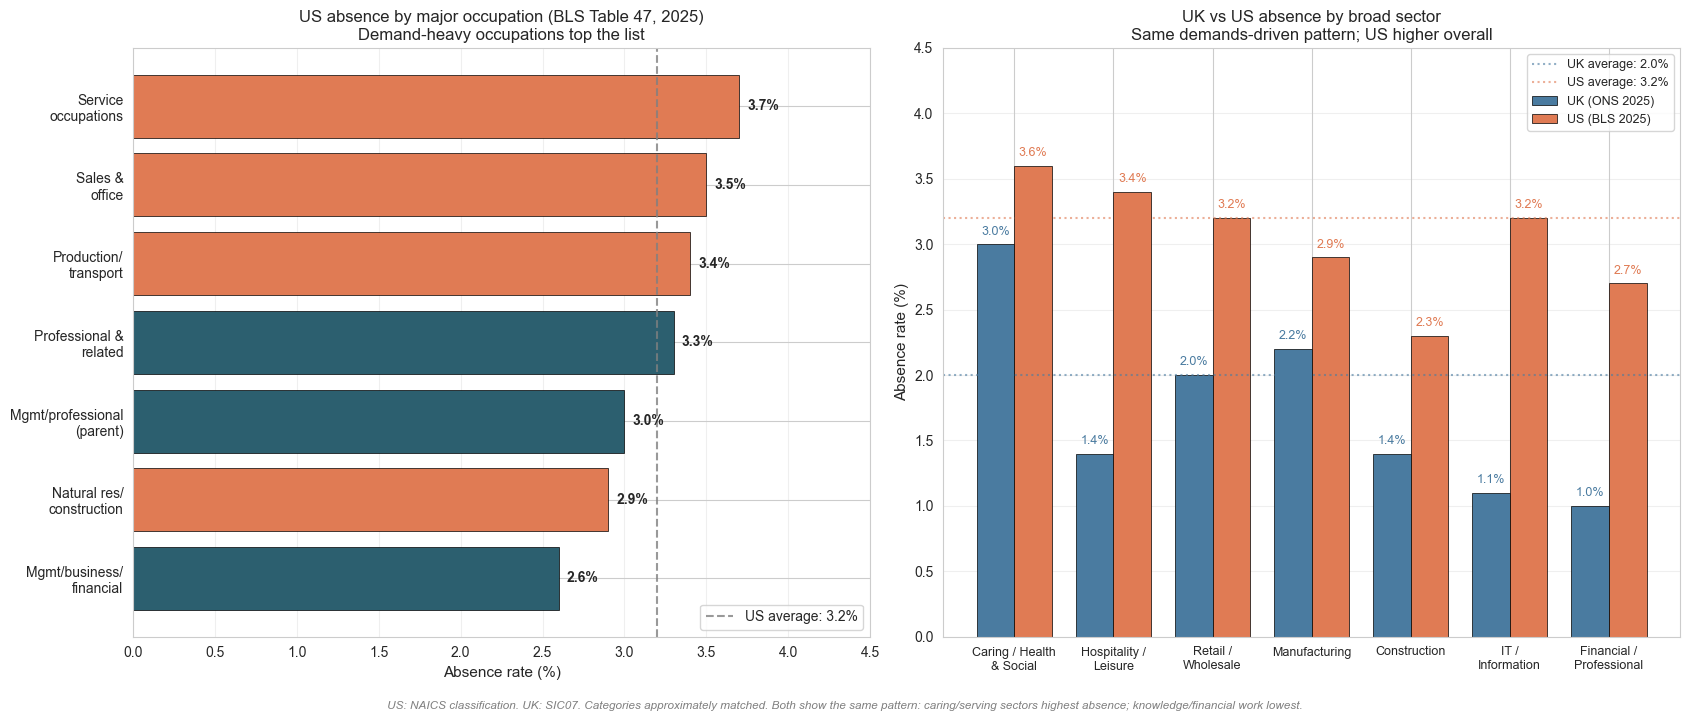


>>> KEY VISUAL FINDING <<<
In both UK and US, caring/service occupations show highest absence.
US Service occupations: 3.7% (highest)
US Mgmt/business/financial: 2.6% (lowest)
Spread: 1.1 percentage points within US, similar to UK's 2.3pp spread

The US sits at a HIGHER absolute level (avg 3.2% vs UK 2.0%) — possibly due to:
  - US has no federal sick pay → workers cover their own absences more visibly
  - Different survey methodology (CPS vs LFS)
  - Bigger gender effect in US data (women 4.0% vs men 2.6%)


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# === Panel 1: US absence by occupation ===
# === Panel 2: UK vs US absence — top demanding sectors ===

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Shorter labels for the chart
us_occ_chart = us_occ_absence.copy()
short_labels = {
    'Management, professional, and related occupations': 'Mgmt/professional\n(parent)',
    'Management, business, and financial operations occupations': 'Mgmt/business/\nfinancial',
    'Professional and related occupations': 'Professional &\nrelated',
    'Service occupations': 'Service\noccupations',
    'Sales and office occupations': 'Sales &\noffice',
    'Natural resources, construction, and maintenance occupations': 'Natural res/\nconstruction',
    'Production, transportation, and material moving occupations': 'Production/\ntransport',
}
us_occ_chart['short_label'] = us_occ_chart['category'].map(short_labels)
us_occ_chart = us_occ_chart.sort_values('absence_total_pct', ascending=True)

# ---- Panel 1: US occupations ----
ax1 = axes[0]
colors = ['#2c5f6f' if 'Mgmt' in lbl or 'Professional' in lbl else '#e07b54' 
          for lbl in us_occ_chart['short_label']]
bars = ax1.barh(us_occ_chart['short_label'], us_occ_chart['absence_total_pct'], 
                color=colors, edgecolor='black', linewidth=0.5)

# US average reference
ax1.axvline(3.2, color='gray', linestyle='--', alpha=0.8, label='US average: 3.2%')

# Annotate bars with values
for bar, val in zip(bars, us_occ_chart['absence_total_pct']):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Absence rate (%)', fontsize=11)
ax1.set_title('US absence by major occupation (BLS Table 47, 2025)\nDemand-heavy occupations top the list',
              fontsize=12)
ax1.set_xlim(0, 4.5)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3, axis='x')

# ---- Panel 2: UK vs US side-by-side ----
ax2 = axes[1]

# Roughly comparable categories — same broad story in both countries
comparison_data = pd.DataFrame({
    'sector': ['Caring / Health\n& Social',
               'Hospitality /\nLeisure',
               'Retail /\nWholesale',
               'Manufacturing',
               'Construction',
               'IT /\nInformation',
               'Financial /\nProfessional'],
    'UK': [3.0, 1.4, 2.0, 2.2, 1.4, 1.1, 1.0],
    'US': [3.6, 3.4, 3.2, 2.9, 2.3, 3.2, 2.7],
})

x = np.arange(len(comparison_data))
width = 0.38

bars_uk = ax2.bar(x - width/2, comparison_data['UK'], width, 
                  label='UK (ONS 2025)', color='#4a7ba0', edgecolor='black', linewidth=0.5)
bars_us = ax2.bar(x + width/2, comparison_data['US'], width, 
                  label='US (BLS 2025)', color='#e07b54', edgecolor='black', linewidth=0.5)

# Reference lines
ax2.axhline(2.0, color='#4a7ba0', linestyle=':', alpha=0.6, label='UK average: 2.0%')
ax2.axhline(3.2, color='#e07b54', linestyle=':', alpha=0.6, label='US average: 3.2%')

# Annotate bars
for bar in bars_uk:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h}%',
             ha='center', va='bottom', fontsize=9, color='#4a7ba0')
for bar in bars_us:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h}%',
             ha='center', va='bottom', fontsize=9, color='#e07b54')

ax2.set_xticks(x)
ax2.set_xticklabels(comparison_data['sector'], fontsize=9)
ax2.set_ylabel('Absence rate (%)', fontsize=11)
ax2.set_title('UK vs US absence by broad sector\nSame demands-driven pattern; US higher overall',
              fontsize=12)
ax2.set_ylim(0, 4.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3, axis='y')

# Caveat below the chart
fig.text(0.5, -0.02,
         "US: NAICS classification. UK: SIC07. Categories approximately matched. "
         "Both show the same pattern: caring/serving sectors highest absence; knowledge/financial work lowest.",
         ha='center', fontsize=8.5, style='italic', color='gray')

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'bls_us_vs_uk_absence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>>> KEY VISUAL FINDING <<<")
print(f"In both UK and US, caring/service occupations show highest absence.")
print(f"US Service occupations: 3.7% (highest)")
print(f"US Mgmt/business/financial: 2.6% (lowest)")
print(f"Spread: 1.1 percentage points within US, similar to UK's 2.3pp spread")
print(f"")
print(f"The US sits at a HIGHER absolute level (avg 3.2% vs UK 2.0%) — possibly due to:")
print(f"  - US has no federal sick pay → workers cover their own absences more visibly")
print(f"  - Different survey methodology (CPS vs LFS)")
print(f"  - Bigger gender effect in US data (women 4.0% vs men 2.6%)")

In [12]:
# Final calibration summary — single table comparing UK and US baselines

# CPS Table 37 — US median weekly earnings (full-time, all workers)
US_MEDIAN_WEEKLY_FT = 1204  # from cpsaat37 row 7, 2025 11-month avg
US_DAILY_FT = US_MEDIAN_WEEKLY_FT / 5  # $240.80
US_ANNUAL_FT = US_MEDIAN_WEEKLY_FT * 52  # $62,608

USD_TO_GBP = 0.78

# Apply BLS verified absence rate (3.2%, 7.7 days)
US_DAYS_ABSENT = 0.032 * 240  # 7.68 days
US_DIRECT_COST_USD = US_DAYS_ABSENT * US_DAILY_FT
US_DIRECT_COST_GBP = US_DIRECT_COST_USD * USD_TO_GBP

print("=" * 80)
print(">>> UK vs US — FULL CALIBRATION SUMMARY <<<")
print("=" * 80)

summary = pd.DataFrame([
    ['Median weekly earnings', '£642.50', '$1,204 (£940)', 'UK ASHE / US CPS Table 37'],
    ['Median daily wage', '£128.50', '$240.80 (£188)', '÷ 5 working days'],
    ['Implied annual gross', '£33,410', '$62,608 (£48,834)', '× 52 weeks'],
    ['', '', '', ''],
    ['Sickness absence rate', '2.0% (ONS)', '3.2% (BLS)', 'Different methodologies'],
    ['Days lost/worker/year', '4.4 (ONS) / 9.4 (CIPD)', '~7.7 (BLS)', '3.2% × 240 working days'],
    ['', '', '', ''],
    ['Direct absence cost/employee/year', '£565 (ONS) / £1,208 (CIPD)', '$1,854 (£1,446)', 'days × daily wage'],
    ['Per 1,000 employees', '£565k / £1.2M', '$1.85M (£1.45M)', ''],
    ['Fully-loaded (× 2.5×)', '£3,020 (CIPD)', '$4,635 (£3,615)', 'Replacement + productivity'],
    ['', '', '', ''],
    ['Annual voluntary turnover', '~13.5% (RTI derived)', '~24% (JOLTS × 12)', 'Direct US measure'],
    ['Regrettable attrition', '~10.5% (UK estimated)', '~18-22% (US estimated)', '~78% of voluntary'],
    ['', '', '', ''],
    ['Intent to leave (EWCS)', '19.8%', 'Not measured', 'Europe only'],
    ['Intent-vs-behaviour gap', '~9.3pp', 'Smaller (intent ≈ behaviour)', 'US labour mobility absorbs intent'],
], columns=['Metric', 'UK', 'US', 'Source / Note'])

print(summary.to_string(index=False))

print(f"\n\n>>> THE TRANSATLANTIC STORY (one sentence each) <<<")
print(f"")
print(f"1. EARNINGS: US median daily wage is ~{US_DAILY_FT * USD_TO_GBP / 128.50:.2f}× UK (£188 vs £128.50/day).")
print(f"")
print(f"2. ABSENCE: US absence rate is higher (3.2% vs 2.0% ONS) but UK CIPD-based")
print(f"   cost converges with US BLS cost — Brits miss more days, Americans cost more per day.")
print(f"")
print(f"3. TURNOVER: US voluntary turnover is ~2× UK — Americans quit far more often.")
print(f"   The Wellmatch product opportunity is structurally larger in the US.")
print(f"")
print(f"4. INTENT-BEHAVIOUR GAP: The Wellmatch early-warning window is bigger in the UK")
print(f"   (intent 19.8% vs behaviour ~10.5% = 9.3pp). US workers act on intent more readily")
print(f"   because the US labour market has lower switching costs.")

>>> UK vs US — FULL CALIBRATION SUMMARY <<<
                           Metric                         UK                           US                     Source / Note
           Median weekly earnings                    £642.50                $1,204 (£940)         UK ASHE / US CPS Table 37
                Median daily wage                    £128.50               $240.80 (£188)                  ÷ 5 working days
             Implied annual gross                    £33,410            $62,608 (£48,834)                        × 52 weeks
                                                                                                                           
            Sickness absence rate                 2.0% (ONS)                   3.2% (BLS)           Different methodologies
            Days lost/worker/year     4.4 (ONS) / 9.4 (CIPD)                   ~7.7 (BLS)           3.2% × 240 working days
                                                                                        